In [5]:
import pandas as pd

df = pd.read_csv("../data/upi_transactions.csv")

print("Dataset loaded successfully!")
print("Total transactions:", len(df))

df.head()

Dataset loaded successfully!
Total transactions: 1000


,transaction_id,amount,transaction_hour,failed_attempts,new_device,unusual_location,transaction_count_1hr,fraud
0,1,15845,8,4,1,0,6,1
1,2,910,4,4,1,0,9,1
2,3,38208,5,2,1,1,1,1
3,4,44782,19,3,1,1,1,1
4,5,11334,1,1,1,1,8,1


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
print("UPI Fraud Statistical Analysis")
print("
Project is ready!")

In [7]:
fraud_counts = df["fraud"].value_counts()

print("Fraud Transaction Counts:")
print(fraud_counts)

Fraud Transaction Counts:
fraud
1    811
0    189
Name: count, dtype: int64


In [8]:
fraud_percentage = (df["fraud"].mean()) * 100

print("Fraud Percentage:", round(fraud_percentage, 2), "%")

Fraud Percentage: 81.1 %


In [9]:
fraud_percentage = (df["fraud"].mean()) * 100

print("Fraud Percentage:", round(fraud_percentage, 2), "%")

Fraud Percentage: 81.1 %


In [10]:
print("Basic Statistics:")
print(df.describe())


Basic Statistics:
       transaction_id        amount  transaction_hour  failed_attempts  \
count     1000.000000   1000.000000        1000.00000       1000.00000   
mean       500.500000  24556.821000          11.30600          2.56300   
std        288.819436  14650.845915           6.93646          1.70086   
min          1.000000     59.000000           0.00000          0.00000   
25%        250.750000  11430.000000           5.00000          1.00000   
50%        500.500000  23915.000000          11.00000          3.00000   
75%        750.250000  37955.250000          17.00000          4.00000   
max       1000.000000  49972.000000          23.00000          5.00000   

        new_device  unusual_location  transaction_count_1hr        fraud  
count  1000.000000       1000.000000            1000.000000  1000.000000  
mean      0.495000          0.486000               7.583000     0.811000  
std       0.500225          0.500054               4.042704     0.391705  
min       0.000

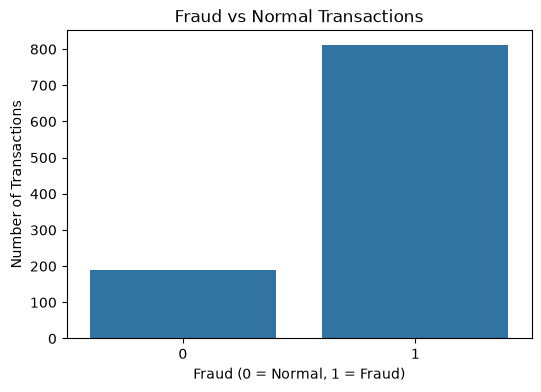

In [11]:
plt.figure(figsize=(6, 4))

sns.countplot(x="fraud", data=df)

plt.title("Fraud vs Normal Transactions")
plt.xlabel("Fraud (0 = Normal, 1 = Fraud)")
plt.ylabel("Number of Transactions")

plt.show()

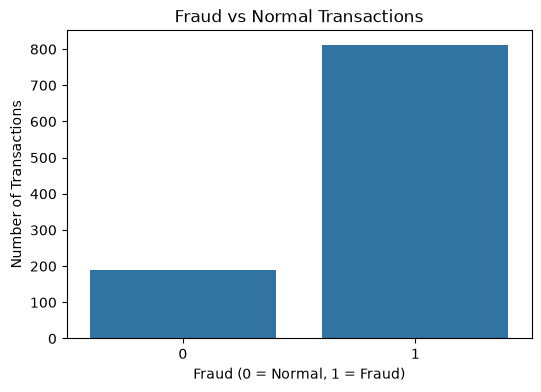

In [12]:
plt.figure(figsize=(6, 4))

sns.countplot(x="fraud", data=df)

plt.title("Fraud vs Normal Transactions")
plt.xlabel("Fraud (0 = Normal, 1 = Fraud)")
plt.ylabel("Number of Transactions")

plt.show()


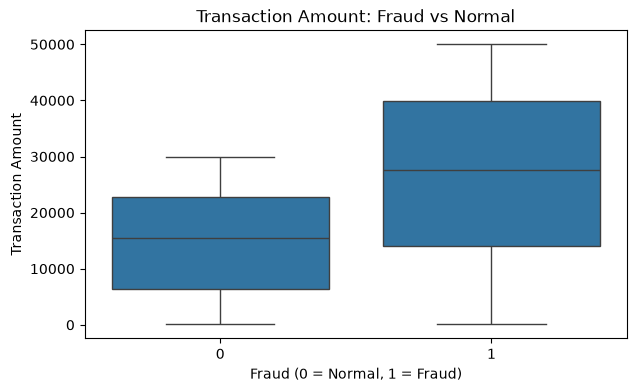

In [13]:
plt.figure(figsize=(7, 4))

sns.boxplot(x="fraud", y="amount", data=df)

plt.title("Transaction Amount: Fraud vs Normal")
plt.xlabel("Fraud (0 = Normal, 1 = Fraud)")
plt.ylabel("Transaction Amount")

plt.show()

In [14]:
fraud_by_type = pd.crosstab(df["transaction_type"], df["fraud"])

print("Fraud by Transaction Type:")
print(fraud_by_type)

KeyError: 'transaction_type'

In [15]:
fraud_by_hour = pd.crosstab(df["transaction_hour"], df["fraud"])

print("Fraud by Transaction Hour:")
print(fraud_by_hour)

Fraud by Transaction Hour:
fraud              0   1
transaction_hour        
0                  5  37
1                 10  37
2                  8  34
3                  9  29
4                 11  34
5                 11  35
6                  8  30
7                 10  43
8                 11  29
9                  4  31
10                11  34
11                10  32
12                11  34
13                 8  33
14                 5  43
15                 2  21
16                 9  40
17                 9  31
18                 5  36
19                 3  35
20                 6  30
21                 9  34
22                 8  33
23                 6  36


In [16]:
failed_fraud = pd.crosstab(df["failed_attempts"], df["fraud"])

print("Failed Attempts vs Fraud:")
print(failed_fraud)


Failed Attempts vs Fraud:
fraud             0    1
failed_attempts         
0                50  106
1                54  118
2                40  101
3                45  136
4                 0  184
5                 0  166


In [17]:
device_fraud = pd.crosstab(df["new_device"], df["fraud"])

print("New Device vs Fraud:")
print(device_fraud)

New Device vs Fraud:
fraud         0    1
new_device          
0           126  379
1            63  432


In [18]:
location_fraud = pd.crosstab(df["unusual_location"], df["fraud"])

print("Unusual Location vs Fraud:")
print(location_fraud)

Unusual Location vs Fraud:
fraud               0    1
unusual_location          
0                 133  381
1                  56  430


In [19]:
count_fraud = pd.crosstab(df["transaction_count_1hr"], df["fraud"])

print("Transaction Count in 1 Hour vs Fraud:")
print(count_fraud)

Transaction Count in 1 Hour vs Fraud:
fraud                   0   1
transaction_count_1hr        
1                      20  55
2                      18  47
3                      23  49
4                      26  39
5                      22  42
6                      22  60
7                      23  46
8                      16  56
9                      19  43
10                      0  75
11                      0  85
12                      0  65
13                      0  78
14                      0  71


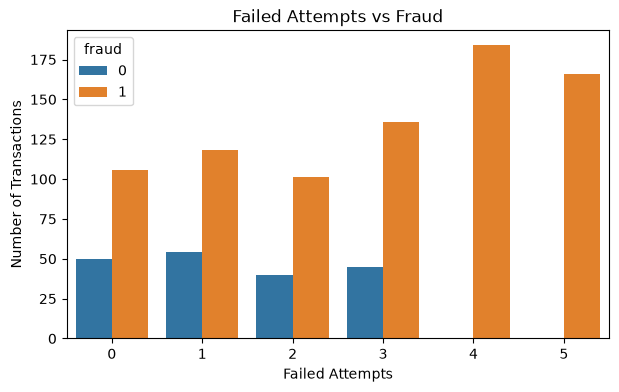

In [20]:
plt.figure(figsize=(7, 4))

sns.countplot(x="failed_attempts", hue="fraud", data=df)

plt.title("Failed Attempts vs Fraud")
plt.xlabel("Failed Attempts")
plt.ylabel("Number of Transactions")

plt.show()

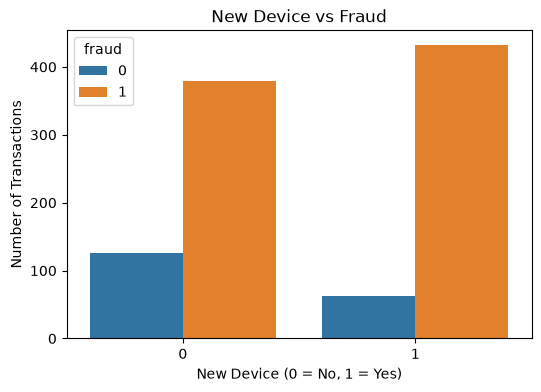

In [21]:
plt.figure(figsize=(6, 4))

sns.countplot(x="new_device", hue="fraud", data=df)

plt.title("New Device vs Fraud")
plt.xlabel("New Device (0 = No, 1 = Yes)")
plt.ylabel("Number of Transactions")

plt.show()

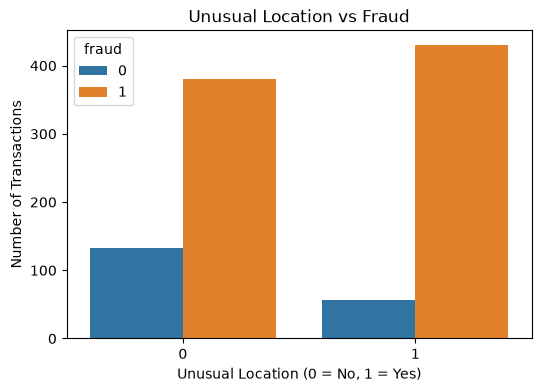

In [22]:
plt.figure(figsize=(6, 4))

sns.countplot(x="unusual_location", hue="fraud", data=df)

plt.title("Unusual Location vs Fraud")
plt.xlabel("Unusual Location (0 = No, 1 = Yes)")
plt.ylabel("Number of Transactions")

plt.show()

In [23]:
correlation = df.corr(numeric_only=True)

print("Correlation with Fraud:")
print(correlation["fraud"].sort_values(ascending=False))

Correlation with Fraud:
fraud                    1.000000
failed_attempts          0.323644
amount                   0.320315
transaction_count_1hr    0.317446
unusual_location         0.183230
new_device               0.156096
transaction_hour         0.044149
transaction_id           0.012852
Name: fraud, dtype: float64


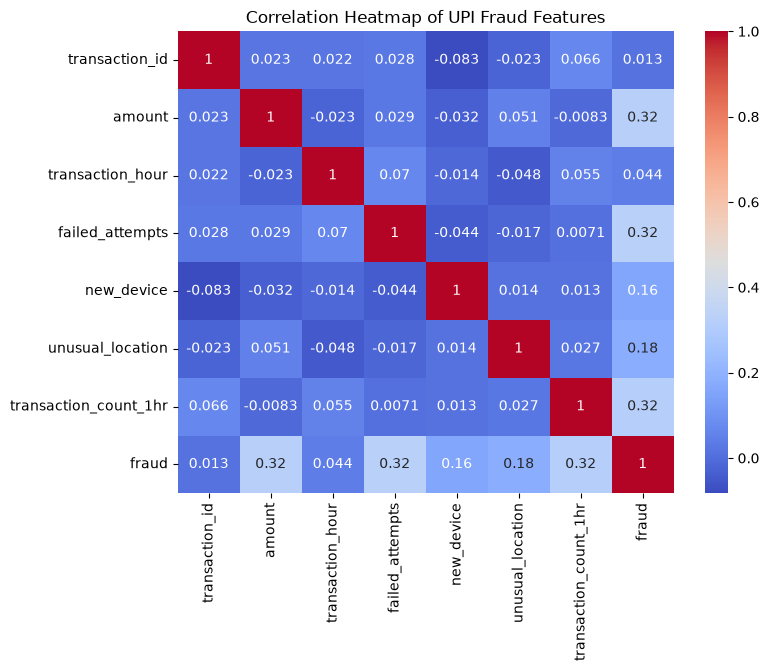

In [25]:
plt.figure(figsize=(8, 6))

sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")

plt.title("Correlation Heatmap of UPI Fraud Features")

plt.show()

In [26]:
print("UPI FRAUD RISK FACTORS")
print("-----------------------")

print("1. Failed Attempts")
print(df.groupby("failed_attempts")["fraud"].mean())

print("\n2. New Device")
print(df.groupby("new_device")["fraud"].mean())

print("\n3. Unusual Location")
print(df.groupby("unusual_location")["fraud"].mean())

print("\n4. Transaction Count in 1 Hour")
print(df.groupby("transaction_count_1hr")["fraud"].mean())

UPI FRAUD RISK FACTORS
-----------------------
1. Failed Attempts
failed_attempts
0    0.679487
1    0.686047
2    0.716312
3    0.751381
4    1.000000
5    1.000000
Name: fraud, dtype: float64

2. New Device
new_device
0    0.750495
1    0.872727
Name: fraud, dtype: float64

3. Unusual Location
unusual_location
0    0.741245
1    0.884774
Name: fraud, dtype: float64

4. Transaction Count in 1 Hour
transaction_count_1hr
1     0.733333
2     0.723077
3     0.680556
4     0.600000
5     0.656250
6     0.731707
7     0.666667
8     0.777778
9     0.693548
10    1.000000
11    1.000000
12    1.000000
13    1.000000
14    1.000000
Name: fraud, dtype: float64


In [27]:
print("FINAL CONCLUSION")
print("----------------")
print("The analysis shows that certain transaction patterns are strongly associated with UPI fraud.")
print("Failed attempts, new devices, unusual locations, and high transaction frequency can act as fraud indicators.")
print("Statistical analysis and visualization help identify suspicious transaction patterns.")
print("These signals can be useful for developing an effective UPI fraud detection system.")

FINAL CONCLUSION
----------------
The analysis shows that certain transaction patterns are strongly associated with UPI fraud.
Failed attempts, new devices, unusual locations, and high transaction frequency can act as fraud indicators.
Statistical analysis and visualization help identify suspicious transaction patterns.
These signals can be useful for developing an effective UPI fraud detection system.


In [28]:
import os

os.makedirs("../images", exist_ok=True)

print("Images folder ready!")

Images folder ready!


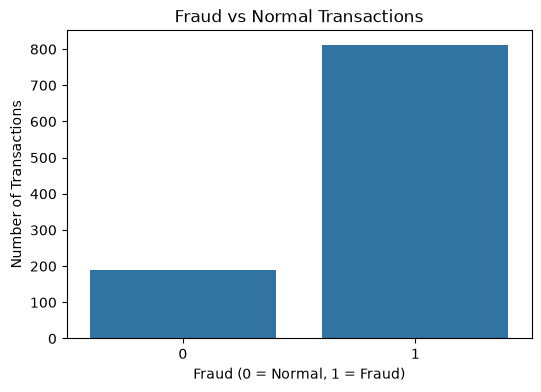

In [29]:
plt.figure(figsize=(6, 4))

sns.countplot(x="fraud", data=df)

plt.title("Fraud vs Normal Transactions")
plt.xlabel("Fraud (0 = Normal, 1 = Fraud)")
plt.ylabel("Number of Transactions")

plt.savefig("../images/fraud_vs_normal.png")
plt.show()

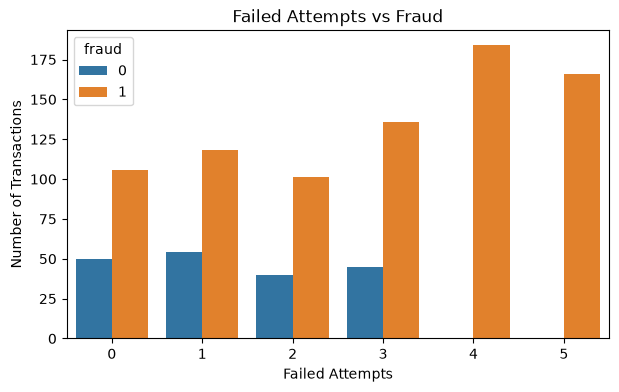

In [30]:
plt.figure(figsize=(7, 4))

sns.countplot(x="failed_attempts", hue="fraud", data=df)

plt.title("Failed Attempts vs Fraud")
plt.xlabel("Failed Attempts")
plt.ylabel("Number of Transactions")

plt.savefig("../images/failed_attempts_vs_fraud.png")
plt.show()

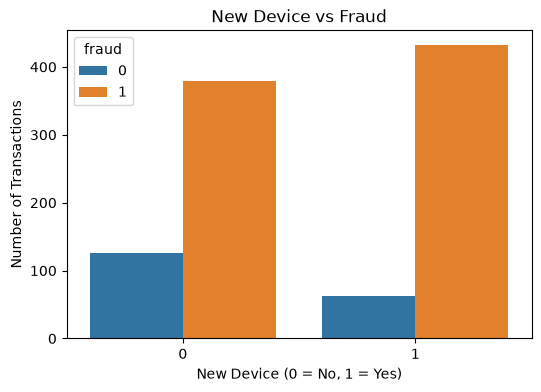

In [31]:
plt.figure(figsize=(6, 4))

sns.countplot(x="new_device", hue="fraud", data=df)

plt.title("New Device vs Fraud")
plt.xlabel("New Device (0 = No, 1 = Yes)")
plt.ylabel("Number of Transactions")

plt.savefig("../images/new_device_vs_fraud.png")
plt.show()

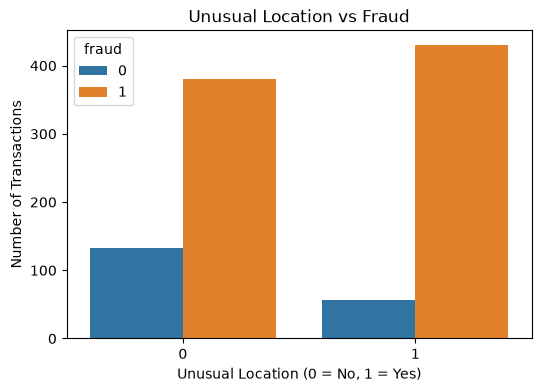

In [32]:
plt.figure(figsize=(6, 4))

sns.countplot(x="unusual_location", hue="fraud", data=df)

plt.title("Unusual Location vs Fraud")
plt.xlabel("Unusual Location (0 = No, 1 = Yes)")
plt.ylabel("Number of Transactions")

plt.savefig("../images/unusual_location_vs_fraud.png")
plt.show()